# Test Data Loading

In [1]:
import cma

### Vessel Data

In [2]:
vessels_pool = cma.read_vessel_class_data()
vessels_pool

       Vessel Type  Vessel Number
0    Rank 1 Vessel             21
1    Rank 2 Vessel             41
2    Rank 3 Vessel             62
3    Rank 4 Vessel             71
4    Rank 5 Vessel             86
5    Rank 6 Vessel             39
6    Rank 7 Vessel             68
7    Rank 8 Vessel             54
8    Rank 9 Vessel             57
9   Rank 10 Vessel             48
10  Rank 11 Vessel             25
11  Rank 12 Vessel             36
12  Rank 13 Vessel             11

### Port Data

In [3]:
portpool = None
_, portpool = cma.read_port_data()
print(portpool.get_number_of_ports())

93


In Total  92  ports are plotted


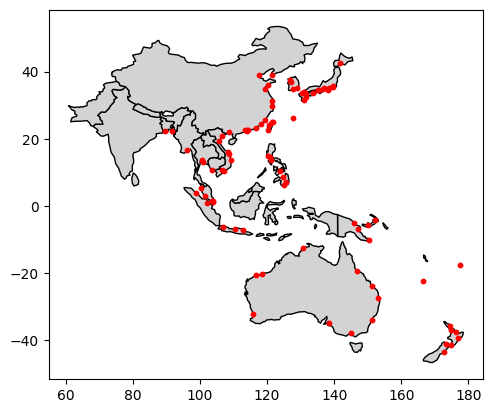

In [4]:
MAP_FILE_PATH = './110m_cultural/ne_110m_admin_0_countries.shp'
asia_pacific_countries = [
	'China','Taiwan', 'Japan', 'South Korea',
	'Vietnam', 'Myanmar', 'Laos', 'Thailand', 'Cambodia',
	'Indonesia', 'Philippines', 'Malaysia', 'Singapore', 'Brunei', 'Timor-Leste',
	'Pakistan', 'India', 'Bangladesh', 'Sri Lanka', 'Nepal','Maldives',
	'Australia', 'Papua New Guinea', 'New Zealand', 'Solomon Islands',
	'Vanuatu', 'Samoa', 'Tonga', 'Tuvalu', 'Nauru', 'Palau', 'Marshall Islands','Kiribati' #, 'Fiji'
]
_, ax, portpool_selected = portpool.plot(MAP_FILE_PATH, asia_pacific_countries, plot_port_id = False)

In [5]:
port_PHMNL = portpool_selected.get_port_by_name('PHMNL')
port_PHMNL.get_port_call_costs(vessels_pool)

[inf, 3, 4, 218, 81, 94, 213, 1, inf, inf, inf, inf, inf]

In [7]:
print(0, len(portpool_selected.filter_by_max_draft(0)))
print(5, len(portpool_selected.filter_by_max_draft(5)))
print(10, len(portpool_selected.filter_by_max_draft(10)))
print(15, len(portpool_selected.filter_by_max_draft(15)))
print(20, len(portpool_selected.filter_by_max_draft(20)))
print(25, len(portpool_selected.filter_by_max_draft(25)))
print(30, len(portpool_selected.filter_by_max_draft(30)))

0 92
5 92
10 83
15 57
20 40
25 40
30 39


In [8]:
print(1000, len(portpool_selected.filtered_by_transship_cost(1000)))
print(500, len(portpool_selected.filtered_by_transship_cost(500)))
print(250, len(portpool_selected.filtered_by_transship_cost(250)))
print(125, len(portpool_selected.filtered_by_transship_cost(125)))
print(75, len(portpool_selected.filtered_by_transship_cost(75)))

1000 92
500 90
250 84
125 64
75 45


### Current Lines Data

In [9]:
current_lines, _ = cma.read_current_line_data(portpool_selected)

46
A3CANL -- [TWKHH, CNXMN, CNSHA, CNNGB, AUSYD, AUMEL, AUBNE]


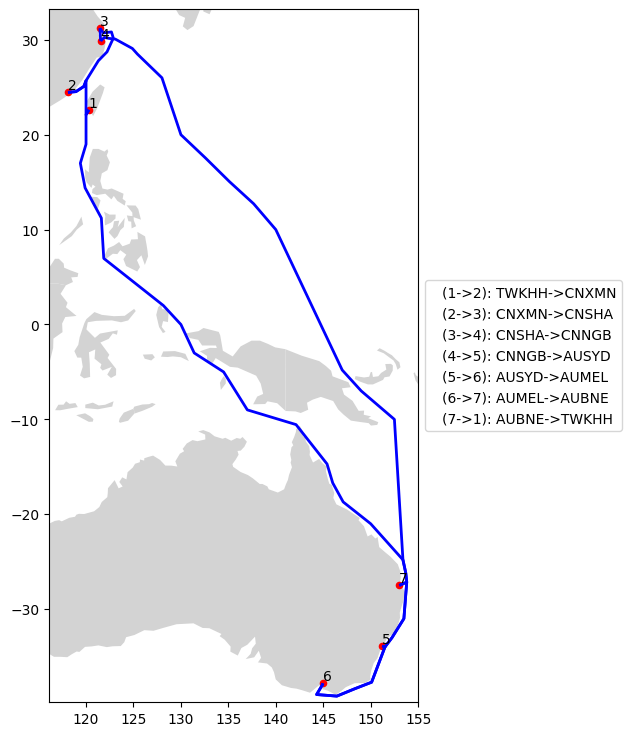

In [10]:
print(len(current_lines))
line = current_lines[0]
print(line)
line.plot(MAP_FILE_PATH, asia_pacific_countries)

### Service Graph

In [11]:
# distance data
dist_mat = cma.read_sailing_distance_data(portpool_selected)

# demand data
demands_dict, total_weekly_demand_mat = cma.read_demand_data(portpool_selected)
# this is not a dense matrix but a sparse matrix
(total_weekly_demand_mat > 0).sum()

/Users/zhuanglinsheng/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/cma/Code/cma/data_reader.py:122: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_file_sail_distance)  # read first table


np.int64(1505)

In [12]:
portgraph = cma.PortGraph(portpool_selected, dist_mat, total_weekly_demand_mat)
# print(portgraph.get_distance_by_id('AUADL', 'AUBNE'))
# print(portgraph.get_demand_by_id('AUADL', 'AUBNE'))
# print(current_lines[0].get_distance(portgraph))

In [13]:
servicegraph = cma.ServiceGraph(current_lines)

In [14]:
# port_1 = portgraph.get_port('SGSIN')
# port_2 = portgraph.get_port('HKHKG')

# trans_ports = portgraph.filtered_by_transship_cost(50)
# print('number of transshipment ports =', len(trans_ports))
# connects = servicegraph.get_paths(port_1, port_2, trans_ports)
# print('number of path =', len(connects))

In [15]:
# connects[11].plot(MAP_FILE_PATH, asia_pacific_countries)

In [16]:
od_pairs, all_paths, unconnected = servicegraph.get_all_paths(portgraph, trans_cost_req = 100)
num_all_paths = 0
for pair, paths in zip(od_pairs, all_paths):
	num_all_paths += len(paths)
print(num_all_paths)

29522


In [17]:
len(unconnected)

285

In [18]:
sol = servicegraph.solve_approximated_cost(portgraph, vessels_pool, False, trans_cost_req=75)

/opt/homebrew/lib/python3.11/site-packages/cvxpy/problems/problem.py:158: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn("Objective contains too many subexpressions. "


                                     CVXPY                                     
                                     v1.6.0                                    
(CVXPY) Feb 22 09:32:00 PM: Your problem has 23299 variables, 25100 constraints, and 0 parameters.
(CVXPY) Feb 22 09:32:00 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 22 09:32:00 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 22 09:32:00 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 22 09:32:00 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 22 09:32:01 PM: Compiling problem (target solver=GLPK

In [19]:
print('Total Cost =', servicegraph.total_cost())

Total Cost = 745130305.5257891


In [20]:
sol.keys()

dict_keys(['line flows', 'demand rounts', 'ships'])

In [29]:
ship_vars = sol['ships']

for line_idx, line in enumerate(current_lines):
	line_ships = ship_vars[line_idx]
	line_ships_val = [float(ship.value) for ship in line_ships]
	print(line.name(), line_ships_val)

A3CANL [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05172180958811614]
A3NANL [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.041188386225523295]
A3SANL [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.29797434166103987]
AAXEANL [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.004321404456448345]
AAXSANL [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.12444294395678596]
AAXWANL [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05914922349763673]
ANZANL [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.008845374746792707]
ANZXANL [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1150573936529372]
BBX2CNC [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.015327481431465227]
BBX3CNC [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.12288993923024984]
BBX6CNC [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05962187711006077]
BBXCNC [0.0